Porównanie modeli:
          Model  Train MSE  Test MSE  Train R²  Test R²
         Linear   0.517933  0.555892  0.612551 0.575788
Ridge (α=100.0)   0.518727  0.553266  0.611957 0.577791


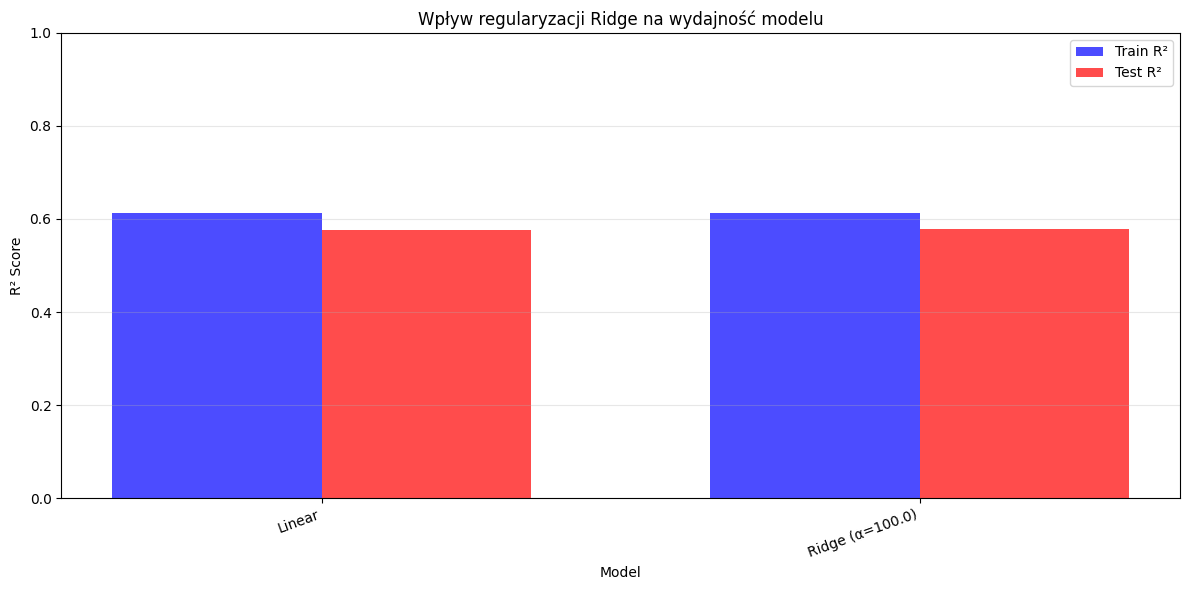

In [2]:
#Ridge Regression podstawy
# Importujemy biblioteki
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
# Wczytujemy dane
california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names
# Podział danych
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
# Standaryzacja (WAŻNE dla Ridge!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model bez regularyzacji
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Model Ridge z różnymi wartościami alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
models = {'Linear': lr}
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
models[f'Ridge (α={alpha})'] = ridge

# Porównanie wyników
results = []
for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    results.append({
    'Model': name,
    'Train MSE': mean_squared_error(y_train, train_pred),
    'Test MSE': mean_squared_error(y_test, test_pred),
    'Train R²': r2_score(y_train, train_pred),
    'Test R²': r2_score(y_test, test_pred)
})
results_df = pd.DataFrame(results)
print("Porównanie modeli:")
print(results_df.to_string(index=False))

# Wykres porównawczy
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(results_df))
width = 0.35
ax.bar(x_pos - width/2, results_df['Train R²'], width, label='Train R²', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, results_df['Test R²'], width, label='Test R²',color='red', alpha=0.7)
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('Wpływ regularyzacji Ridge na wydajność modelu')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('ridge_comparison.png', dpi=100)
plt.show()